In [2]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.animation as animation
from matplotlib import rc
rc('animation', html='jshtml')

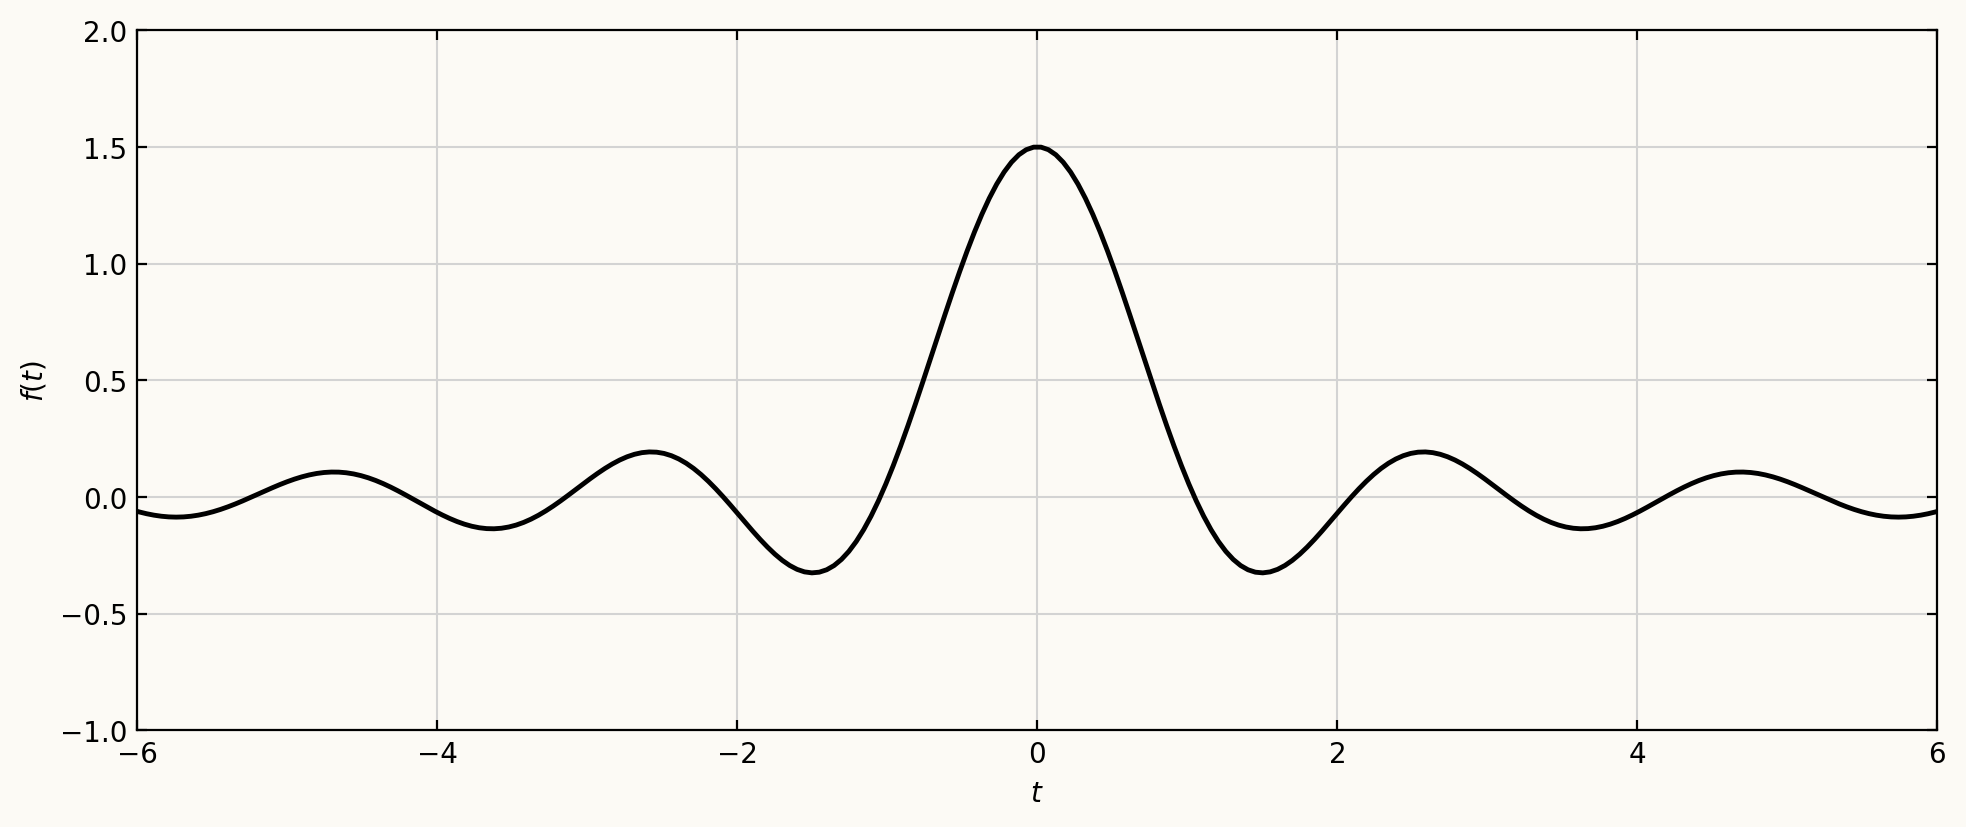

In [3]:
def f(t):
    return 0.5 * np.sin(3 * t) * np.power(t, -1)

#Data
t = np.linspace(-2 * np.pi, 2 * np.pi, 256)
y = f(t)

# Creamos la figura con un tamaño específico y un color de fondo
fig = plt.figure(figsize=(9, 3.5), dpi=200, facecolor='#fcfaf5')  # Fijar tamaño en píxeles

# Creamos los ejes con tamaño específico, centrados, y en la proporción deseada
ax = fig.add_axes([0.0, 0.0, 1.0, 1.0], facecolor='#fcfaf5')  # Posición y tamaño de ax


# Configuración de los límites y etiquetas de los ejes
ax.set(xlim=(-6, 6), ylim=(-1, 2), xlabel=r'$t$', ylabel=r'$f(t)$')

# Mostrar los ticks en los cuatro lados
ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)

# Añadir la cuadrícula
ax.grid(color='lightgray', linestyle='-', linewidth=0.75)

# Graficar los datos
ax.plot(t, y, color='#000000', linewidth=1.75)

# Mostrar la figura
plt.show()


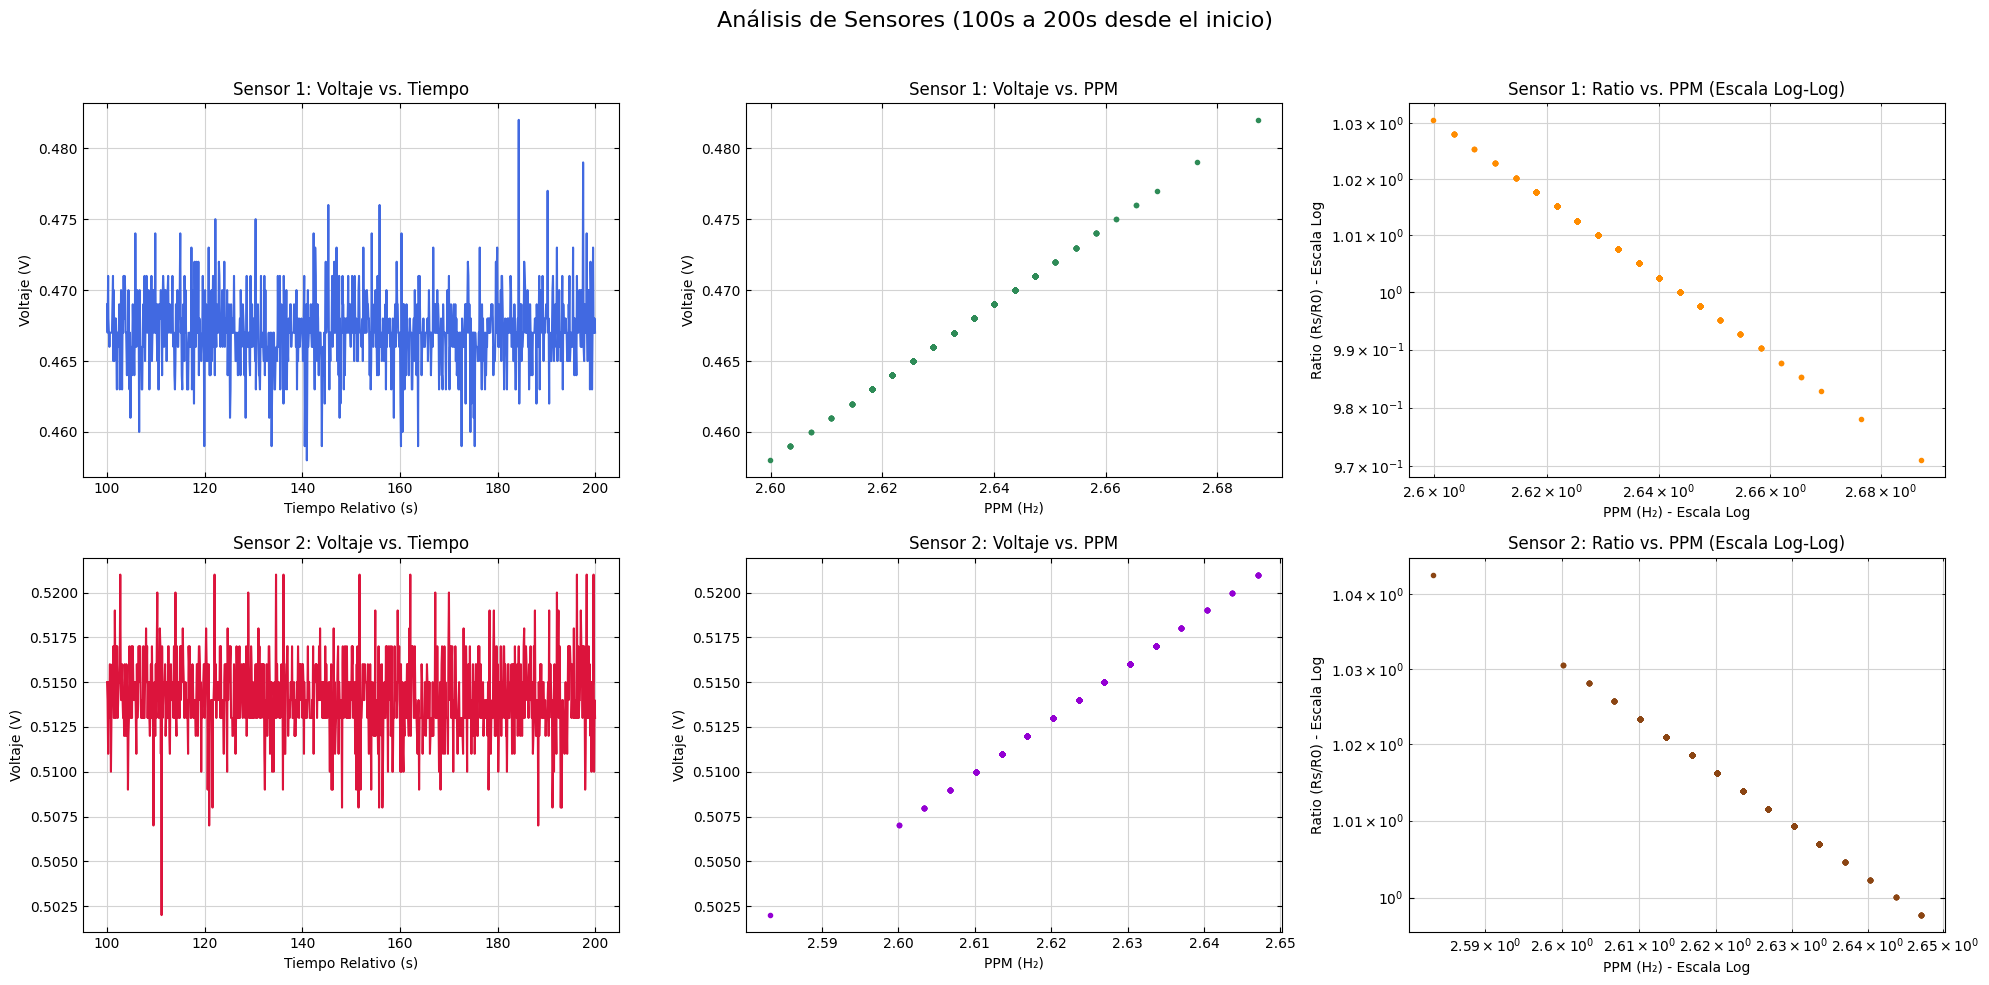

In [7]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Cargar y Preparar los Datos ---
try:
    # Cargar el archivo JSON
    df = pd.read_json('sensor_data.json')
except FileNotFoundError:
    print("Error: No se encontró el archivo 'sensor_data.json'. Asegúrate de que está en la misma carpeta.")
    exit()

# --- 2. Procesar Timestamps y Definir la Ventana de Tiempo ---

# Convertir la columna de texto 'timestamp' a objetos datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Ordenar por si acaso los datos no estuvieran en orden
df = df.sort_values(by='timestamp').reset_index(drop=True)

# Obtener el primer timestamp como punto de referencia
t_inicial = df['timestamp'].iloc[0]

# Definir la ventana de tiempo para el filtro: de 100 a 200 segundos después del inicio
t_start_filter = t_inicial + pd.Timedelta(seconds=100)
t_end_filter = t_inicial + pd.Timedelta(seconds=200)

# --- 3. Filtrar los Datos por Timestamp ---
df_filtered = df[(df['timestamp'] >= t_start_filter) & (df['timestamp'] <= t_end_filter)].copy()


# Filtrar valores de PPM no positivos para evitar errores en la escala logarítmica
df_filtered = df_filtered[df_filtered['ppm_h2_sensor1'] > 0]
df_filtered = df_filtered[df_filtered['ppm_h2_sensor2'] > 0]

if df_filtered.empty:
    print("No se encontraron datos en la ventana de tiempo de 100s a 200s desde el inicio.")
    exit()
    
# Crear el eje de tiempo relativo en segundos para los gráficos
df_filtered['time_s'] = (df_filtered['timestamp'] - t_inicial).dt.total_seconds()


# --- 4. Crear las Gráficas (Esta sección no cambia) ---
fig, ax = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle('Análisis de Sensores (100s a 200s desde el inicio)', fontsize=16)

# --- Gráficas para el Sensor 1 (Primera Fila) ---
ax[0, 0].plot(df_filtered['time_s'], df_filtered['volt_mq1'], color='royalblue')
ax[0, 0].set_title('Sensor 1: Voltaje vs. Tiempo')
ax[0, 0].set_xlabel('Tiempo Relativo (s)')
ax[0, 0].set_ylabel('Voltaje (V)')

ax[0, 1].plot(df_filtered['ppm_h2_sensor1'], df_filtered['volt_mq1'], 'o', color='seagreen', markersize=3)
ax[0, 1].set_title('Sensor 1: Voltaje vs. PPM')
ax[0, 1].set_xlabel('PPM (H₂)')
ax[0, 1].set_ylabel('Voltaje (V)')

ax[0, 2].plot(df_filtered['ppm_h2_sensor1'], df_filtered['ratio_h2_sensor1'], 'o', color='darkorange', markersize=3)
ax[0, 2].set_title('Sensor 1: Ratio vs. PPM (Escala Log-Log)')
ax[0, 2].set_xlabel('PPM (H₂) - Escala Log')
ax[0, 2].set_ylabel('Ratio (Rs/R0) - Escala Log')
ax[0, 2].set_xscale('log')
ax[0, 2].set_yscale('log')

# --- Gráficas para el Sensor 2 (Segunda Fila) ---
ax[1, 0].plot(df_filtered['time_s'], df_filtered['volt_mq2'], color='crimson')
ax[1, 0].set_title('Sensor 2: Voltaje vs. Tiempo')
ax[1, 0].set_xlabel('Tiempo Relativo (s)')
ax[1, 0].set_ylabel('Voltaje (V)')

ax[1, 1].plot(df_filtered['ppm_h2_sensor2'], df_filtered['volt_mq2'], 'o', color='darkviolet', markersize=3)
ax[1, 1].set_title('Sensor 2: Voltaje vs. PPM')
ax[1, 1].set_xlabel('PPM (H₂)')
ax[1, 1].set_ylabel('Voltaje (V)')

ax[1, 2].plot(df_filtered['ppm_h2_sensor2'], df_filtered['ratio_h2_sensor2'], 'o', color='saddlebrown', markersize=3)
ax[1, 2].set_title('Sensor 2: Ratio vs. PPM (Escala Log-Log)')
ax[1, 2].set_xlabel('PPM (H₂) - Escala Log')
ax[1, 2].set_ylabel('Ratio (Rs/R0) - Escala Log')
ax[1, 2].set_xscale('log')
ax[1, 2].set_yscale('log')

# --- 5. Aplicar Estilo y Mostrar (Esta sección no cambia) ---
for row in ax:
    for subplot in row:
        subplot.grid(True, which="both", ls="-", color='lightgray')
        subplot.tick_params(axis='both', which='both', direction='in', top=True, right=True)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


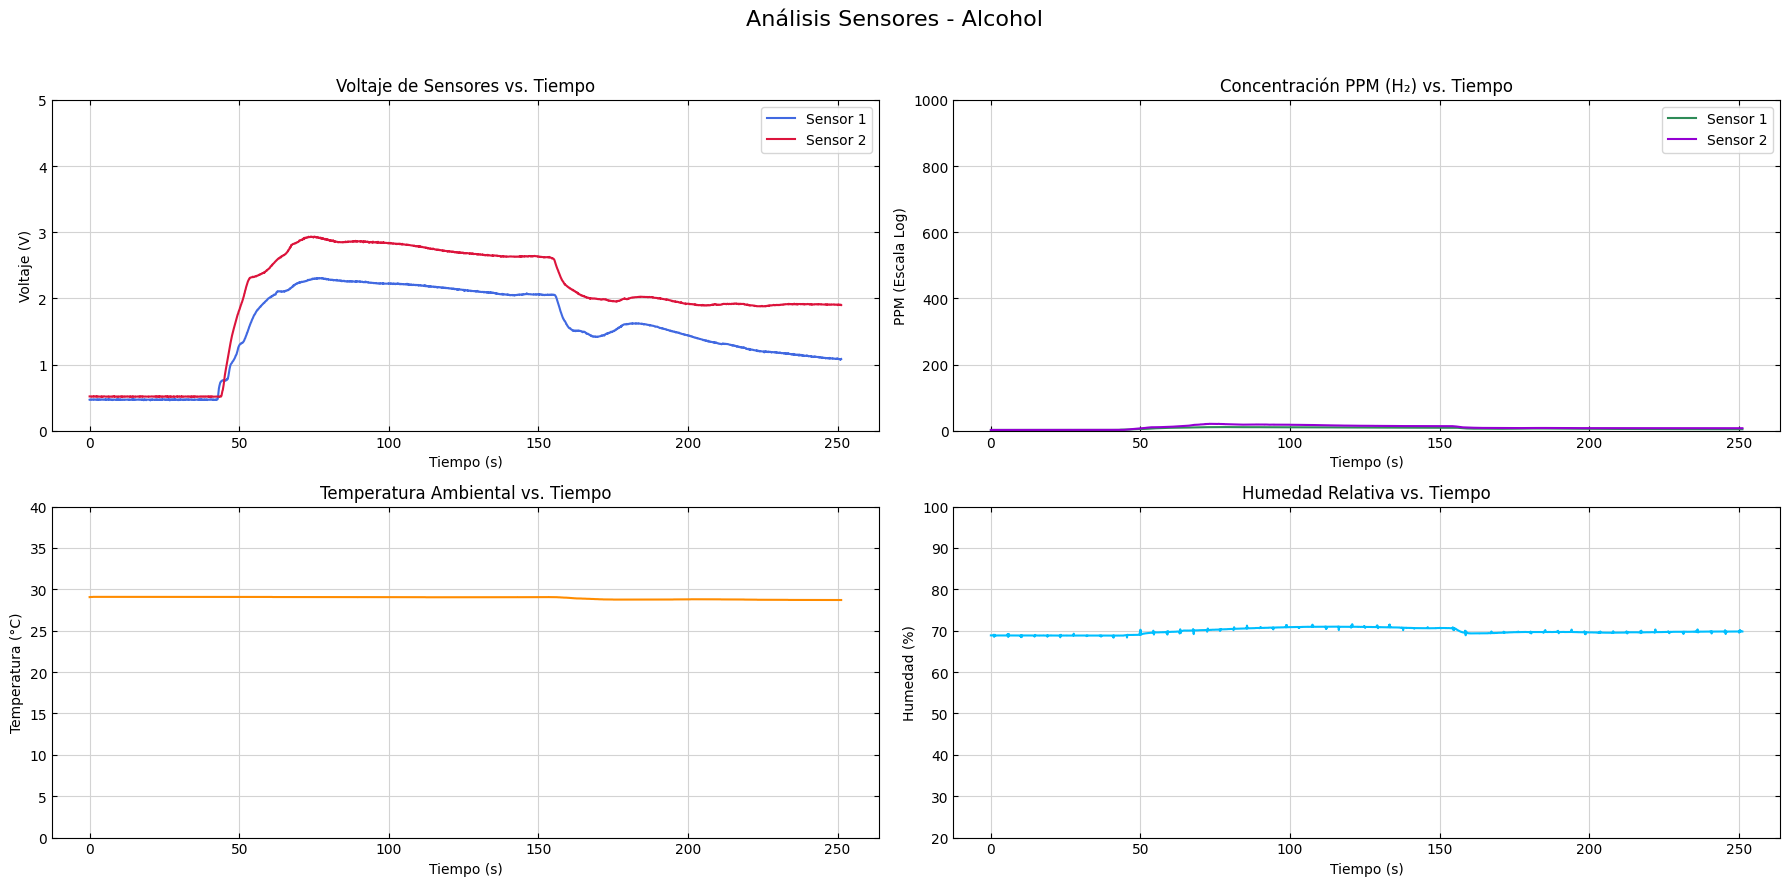

In [42]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Cargar y Preparar los Datos ---
try:
    # Cargar el archivo JSON usando pandas
    df = pd.read_json('sensor_data_alcohol.json')
except FileNotFoundError:
    print("Error: No se encontró el archivo 'sensor_data.json'. Asegúrate de que está en la misma carpeta.")
    exit()

# --- 2. Preparar los Datos (Sin Filtro de Contador) ---
# Usar una copia de todos los datos del DataFrame original
df_filtered = df.copy()

# Filtrar valores de PPM no positivos para evitar errores en la escala logarítmica
df_filtered = df_filtered[df_filtered['ppm_h2_sensor1'] > 0]
df_filtered = df_filtered[df_filtered['ppm_h2_sensor2'] > 0]

if df_filtered.empty:
    print("No se encontraron datos válidos para graficar.")
    exit()
    
# Crear una columna de tiempo en segundos a partir del contador
df_filtered['time_s'] = df_filtered['contador'] * 0.1


# --- 3. Crear las Gráficas ---
# Crear una figura con una cuadrícula de 2x2 para el nuevo panel
fig, ax = plt.subplots(2, 2, figsize=(18, 9))
fig.suptitle('Análisis Sensores - Alcohol', fontsize=16)

# --- Gráfico 1 (Arriba Izquierda): Voltaje vs. Tiempo ---
ax[0, 0].plot(df_filtered['time_s'], df_filtered['volt_mq1'], color='royalblue', label='Sensor 1')
ax[0, 0].plot(df_filtered['time_s'], df_filtered['volt_mq2'], color='crimson', label='Sensor 2')
ax[0, 0].set_title('Voltaje de Sensores vs. Tiempo')
ax[0, 0].set_xlabel('Tiempo (s)')
ax[0, 0].set_ylabel('Voltaje (V)')
ax[0, 0].set_ylim(0, 5) 
ax[0, 0].legend()


# --- Gráfico 2 (Arriba Derecha): PPM vs. Tiempo ---
ax[0, 1].plot(df_filtered['time_s'], df_filtered['ppm_h2_sensor1'], color='seagreen', label='Sensor 1')
ax[0, 1].plot(df_filtered['time_s'], df_filtered['ppm_h2_sensor2'], color='darkviolet', label='Sensor 2')
ax[0, 1].set_title('Concentración PPM (H₂) vs. Tiempo')
ax[0, 1].set_xlabel('Tiempo (s)')
ax[0, 1].set_ylabel('PPM (Escala Log)')
#ax[0, 1].set_yscale('log') # Escala logarítmica para mejor visualización
ax[0, 1].set_ylim(0, 1000) 
ax[0, 1].legend()

# --- Gráfico 3 (Abajo Izquierda): Temperatura vs. Tiempo ---
ax[1, 0].plot(df_filtered['time_s'], df_filtered['temp'], color='darkorange')
ax[1, 0].set_title('Temperatura Ambiental vs. Tiempo')
ax[1, 0].set_xlabel('Tiempo (s)')
ax[1, 0].set_ylabel('Temperatura (°C)')
ax[1, 0].set_ylim(0,40) 

# --- Gráfico 4 (Abajo Derecha): Humedad vs. Tiempo ---
ax[1, 1].plot(df_filtered['time_s'], df_filtered['hum'], color='deepskyblue')
ax[1, 1].set_title('Humedad Relativa vs. Tiempo')
ax[1, 1].set_xlabel('Tiempo (s)')
ax[1, 1].set_ylabel('Humedad (%)')
ax[1, 1].set_ylim(20,100) 

# --- 4. Aplicar Estilo y Mostrar ---
# Aplicar el estilo de cuadrícula y ticks a todos los gráficos
# El array 'ax' ahora es bidimensional (2x2)
for row in ax:
    for subplot in row:
        subplot.grid(True, which="both", ls="-", color='lightgray')
        subplot.tick_params(axis='both', which='both', direction='in', top=True, right=True)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

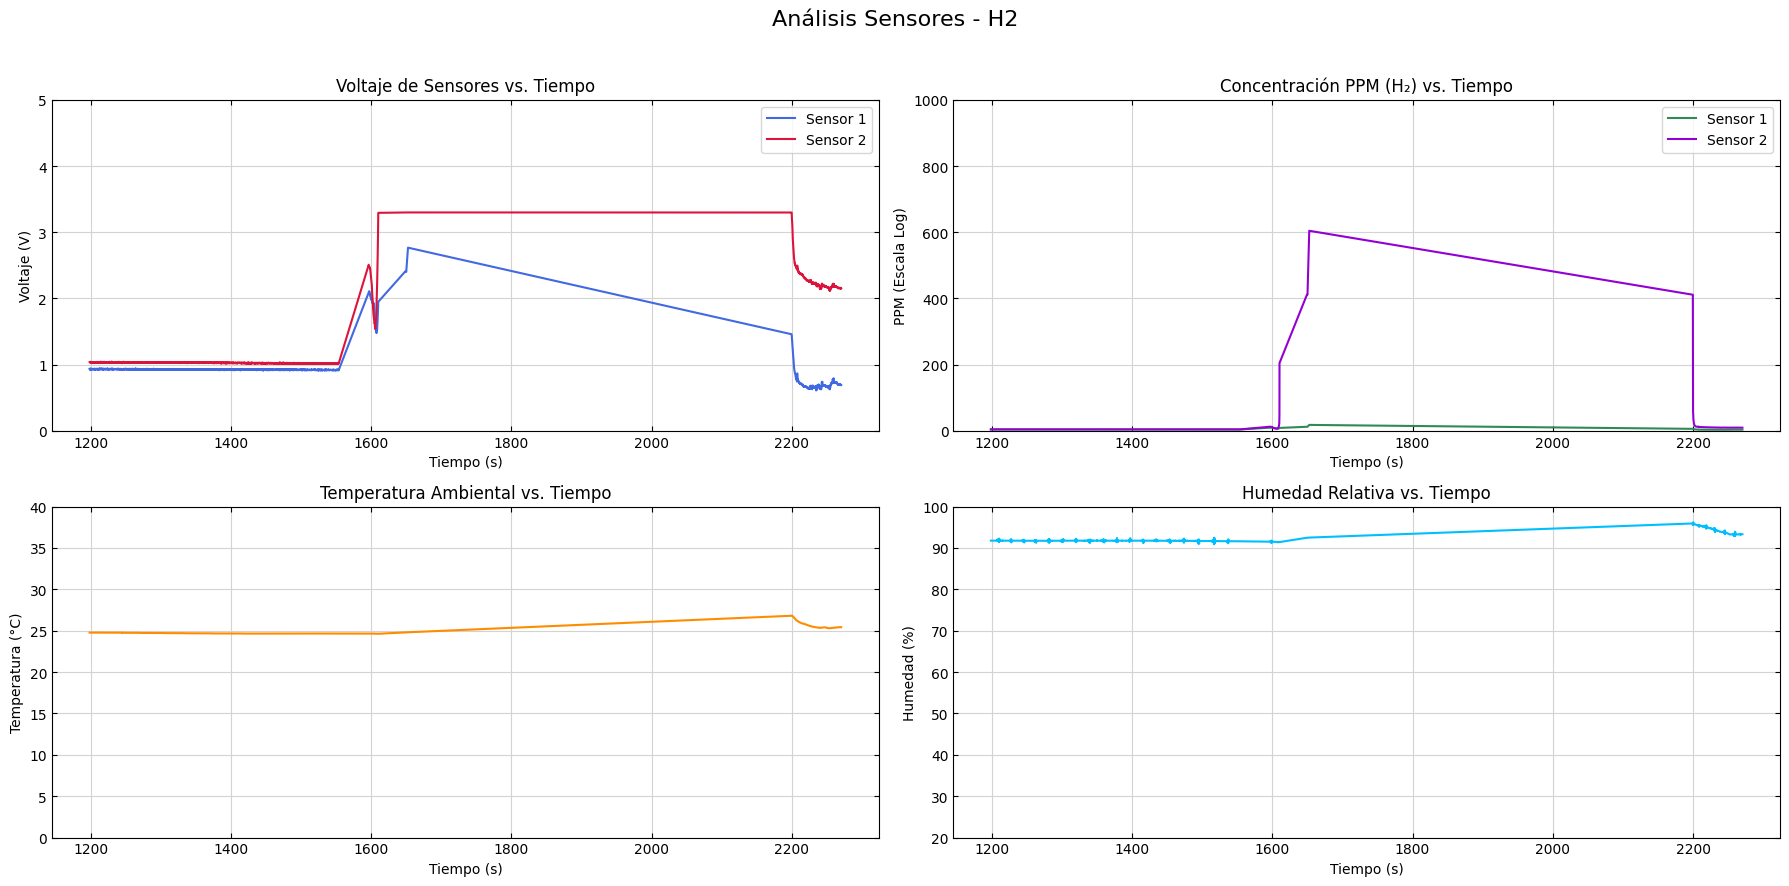

In [41]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Cargar y Preparar los Datos ---
try:
    # Cargar el archivo JSON usando pandas
    df = pd.read_json('sensor_data_h2.json')
except FileNotFoundError:
    print("Error: No se encontró el archivo 'sensor_data.json'. Asegúrate de que está en la misma carpeta.")
    exit()

# --- 2. Preparar los Datos (Sin Filtro de Contador) ---
# Usar una copia de todos los datos del DataFrame original
df_filtered = df.copy()

# Filtrar valores de PPM no positivos para evitar errores en la escala logarítmica
df_filtered = df_filtered[df_filtered['ppm_h2_sensor1'] > 0]
df_filtered = df_filtered[df_filtered['ppm_h2_sensor2'] > 0]

if df_filtered.empty:
    print("No se encontraron datos válidos para graficar.")
    exit()
    
# Crear una columna de tiempo en segundos a partir del contador
df_filtered['time_s'] = df_filtered['contador'] * 0.1


# --- 3. Crear las Gráficas ---
# Crear una figura con una cuadrícula de 2x2 para el nuevo panel
fig, ax = plt.subplots(2, 2, figsize=(18, 9))
fig.suptitle('Análisis Sensores - H2', fontsize=16)

# --- Gráfico 1 (Arriba Izquierda): Voltaje vs. Tiempo ---
ax[0, 0].plot(df_filtered['time_s'], df_filtered['volt_mq1'], color='royalblue', label='Sensor 1')
ax[0, 0].plot(df_filtered['time_s'], df_filtered['volt_mq2'], color='crimson', label='Sensor 2')
ax[0, 0].set_title('Voltaje de Sensores vs. Tiempo')
ax[0, 0].set_xlabel('Tiempo (s)')
ax[0, 0].set_ylabel('Voltaje (V)')
ax[0, 0].set_ylim(0, 5) 
ax[0, 0].legend()


# --- Gráfico 2 (Arriba Derecha): PPM vs. Tiempo ---
ax[0, 1].plot(df_filtered['time_s'], df_filtered['ppm_h2_sensor1'], color='seagreen', label='Sensor 1')
ax[0, 1].plot(df_filtered['time_s'], df_filtered['ppm_h2_sensor2'], color='darkviolet', label='Sensor 2')
ax[0, 1].set_title('Concentración PPM (H₂) vs. Tiempo')
ax[0, 1].set_xlabel('Tiempo (s)')
ax[0, 1].set_ylabel('PPM (Escala Log)')
#ax[0, 1].set_yscale('log') # Escala logarítmica para mejor visualización
ax[0, 1].set_ylim(0, 1000) 
ax[0, 1].legend()

# --- Gráfico 3 (Abajo Izquierda): Temperatura vs. Tiempo ---
ax[1, 0].plot(df_filtered['time_s'], df_filtered['temp'], color='darkorange')
ax[1, 0].set_title('Temperatura Ambiental vs. Tiempo')
ax[1, 0].set_xlabel('Tiempo (s)')
ax[1, 0].set_ylabel('Temperatura (°C)')
ax[1, 0].set_ylim(0,40) 

# --- Gráfico 4 (Abajo Derecha): Humedad vs. Tiempo ---
ax[1, 1].plot(df_filtered['time_s'], df_filtered['hum'], color='deepskyblue')
ax[1, 1].set_title('Humedad Relativa vs. Tiempo')
ax[1, 1].set_xlabel('Tiempo (s)')
ax[1, 1].set_ylabel('Humedad (%)')
ax[1, 1].set_ylim(20,100) 

# --- 4. Aplicar Estilo y Mostrar ---
# Aplicar el estilo de cuadrícula y ticks a todos los gráficos
# El array 'ax' ahora es bidimensional (2x2)
for row in ax:
    for subplot in row:
        subplot.grid(True, which="both", ls="-", color='lightgray')
        subplot.tick_params(axis='both', which='both', direction='in', top=True, right=True)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()